In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from utils import generate_sales_data, generate_weekcover_data
import matplotlib.pyplot as plt
import seaborn as sns


## Fake Data
This is completely AI generated.

In [3]:
df_sales = generate_sales_data()
df_wc = generate_weekcover_data()

In [4]:
df_wc.head()

,customer_key,week_start,product_key,weekcover
0,1,2024-01-01,1,3.208993
1,1,2024-01-01,2,0.000000
2,1,2024-01-01,3,4.546195
3,1,2024-01-08,1,5.116536
4,1,2024-01-08,2,0.000000


In [5]:
df_sales.head()

,customer_key,product_key,product_name,revenue,sales_date,discount_pcnt
0,1,1,Fanta,0.956981,2024-01-01,2.888159
1,1,2,Sprite,2.787535,2024-01-01,2.888159
2,1,3,Coke,10.326597,2024-01-01,2.888159
3,1,1,Fanta,86.402983,2024-01-02,4.204544
4,1,2,Sprite,197.760761,2024-01-02,4.204544


## Create Panel

We want our final data for regression to look like:

$Y_i = \beta_0 +\beta_1D_{WCi} + \beta_2WC_i + ... + \epsilon_i$
- $Y_i$: 
    - NorthStar: Revenue for product i, time t (items sold at the shop this week)
    - Secondary: Week Cover (Next Week) for product i, time t (Week Cover calculated at beginning of next week)
    - Guardrail: Discount, Visits 
- $WC_i$: Week cover for product i,time t (Week Cover calculated at beginning of this week)
- $D_{WCi}$: Running variable threshold. (>2)
- Outlet
- Product
- Date

Panel will be on a weekly level

In [6]:
### -- Sales panel -- ##

# convert sales data to weekly
df_sales_w = df_sales.copy()

# convert date to its week-year where Monday is first day of week
df_sales_w["year_week"] = df_sales_w["sales_date"].dt.strftime('%Y-%W')

# This is the level of our desired panel
panel_ids = ['customer_key', 'product_key', 'year_week']

df_sales_w = df_sales_w.groupby(panel_ids).agg(
    revenue=('revenue', 'sum'),
    discount_pcnt=('discount_pcnt', 'mean')
).reset_index()

## -- Week Cover panel -- ##

df_wc_w = df_wc.copy()
df_wc_w["year_week"] = df_wc["week_start"].dt.strftime("%Y-%W")
df_wc_w.drop(columns='week_start', inplace=True)

## -- JOIN weekcover to sales -- 
df_panel = df_sales_w.merge(df_wc_w, how = "inner", on = panel_ids)


## -- Create RD Threshold --
# If WC less or equal than 2, Outlet receives treatment.
df_panel["D_wc"] = (df_panel["weekcover"] <= 2) * 1

df_panel["D_wc"] = (df_panel["weekcover"] <= 2) * 1

df_panel.head()

## -- Add Week cover of next week to each row and drop nulls. --

df_panel.sort_values(by=panel_ids)
panel_ids_no_dates = panel_ids.copy()
panel_ids_no_dates.remove("year_week")
df_panel["weekcover_lead"] = df_panel.groupby(panel_ids_no_dates)['weekcover'].shift(-1)
df_panel = df_panel.dropna(subset=["weekcover_lead"])

In [7]:
df_panel.head()

,customer_key,product_key,year_week,revenue,discount_pcnt,weekcover,D_wc,weekcover_lead
0,1,1,2024-01,1674.253912,2.489084,3.208993,0,5.116536
1,1,1,2024-02,2068.642666,2.143920,5.116536,0,2.678363
2,1,1,2024-03,448.278916,2.746601,2.678363,0,0.000000
3,1,1,2024-04,1010.627706,2.828551,0.000000,1,2.492934
4,1,1,2024-05,2862.857522,2.091919,2.492934,0,0.000000


## Simple Model

In [ ]:
simple_model_formula = "weekcover_lead ~ D_wc + weekcover + C(year_week) + C(product)"
model = smf.ols(simple_model_formula, data=df_panel).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_panel["customer_key"]}
)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         weekcover_lead   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.265
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.48e-60
Time:                        21:44:54   Log-Likelihood:            -1.0828e+06
No. Observations:              467020   AIC:                         2.166e+06
Df Residuals:                  466862   BIC:                         2.168e+06
Df Model:                         157                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [32]:
model.params[["D_wc", "weekcover"]]

D_wc        -0.042645
weekcover    0.081255
dtype: float64

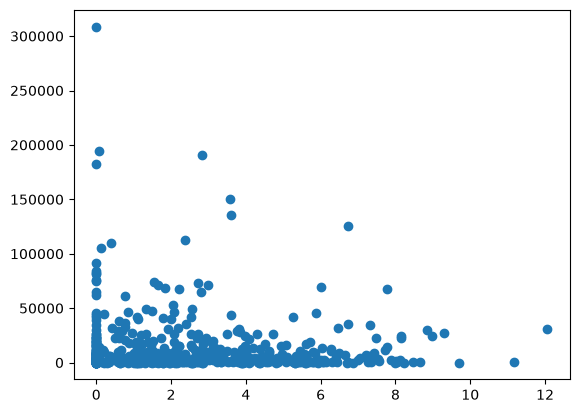

In [12]:
df_panel_sample = df_panel.sample(500)
plt.scatter(df_panel_sample["weekcover"], df_panel_sample["revenue"])

Fixed effects is not a core requirement for causal identification. Why is it important to use it?
- It improves precision by absorbing large sources of variance across time/outlets/products. Similar to CUPED in this case.

However, it has some trade-offs:
- You may remove your identifying variation if treatment doesn’t vary within customer/product/time. i.e. 
    - all users are out of stock at the same time.
    - one user is always below 2 or above 2.
    - one product only has one week of stock.